In [1]:
import pandas as pd
import numpy as np
df = pd.read_excel("pbldataset.xlsx")
df


,CUSTOMER_ID,TOTAL_SPENDING,FREQUENCY,RETURN_RATIO,PURCHASE_INTENSITY,AVG_ORDER_VALUE,AVG_PURCHASE_GAP,ONE_TIME_CUSTOMER
0,12346,270.40,1,0.500000,6.000000,45.066667,45.000000,1
1,12747,59992.40,11,0.071730,21.545455,253.132489,36.300000,0
2,12748,1839408.35,216,0.068624,50.462963,168.753060,1.382488,0
3,12749,169590.85,7,0.061144,72.428571,334.498718,29.428571,0
4,12820,13109.20,4,0.093458,26.750000,122.515888,107.333333,0
...,...,...,...,...,...,...,...,...
3936,18280,7361.25,1,0.000000,25.000000,294.450000,45.000000,1
3937,18281,2176.20,1,0.000000,25.000000,87.048000,45.000000,1
3938,18282,3532.10,3,0.076923,8.666667,135.850000,59.000000,0
3939,18283,163941.05,15,0.073990,117.133333,93.307371,21.800000,0


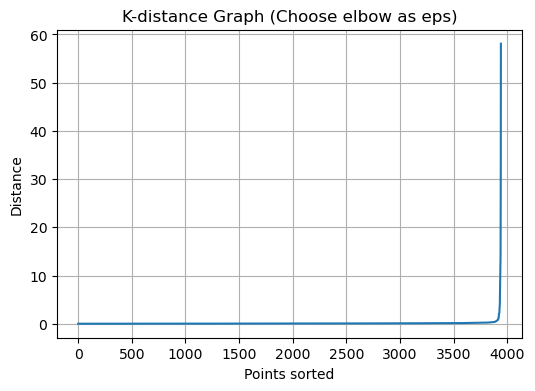

Unique labels: [-1  0]
Number of clusters: 1
Noise points: 31
Not enough clusters for silhouette score


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

df = pd.read_excel("pbldataset.xlsx")

features = [
    'TOTAL_SPENDING',
    'FREQUENCY',
    'AVG_ORDER_VALUE',
    'AVG_PURCHASE_GAP'
]

X = df[features].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(6,4))
plt.plot(distances)
plt.title("K-distance Graph (Choose elbow as eps)")
plt.xlabel("Points sorted")
plt.ylabel("Distance")
plt.grid()
plt.show()

eps_value = 0.8 
db = DBSCAN(eps=eps_value, min_samples=10)

labels = db.fit_predict(X_scaled)

df['Cluster'] = labels

print("Unique labels:", np.unique(labels))
print("Number of clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise points:", list(labels).count(-1))

mask = labels != -1

if len(set(labels[mask])) > 1:
    score = silhouette_score(X_scaled[mask], labels[mask])
    print("Silhouette Score:", score)
else:
    print("Not enough clusters for silhouette score")

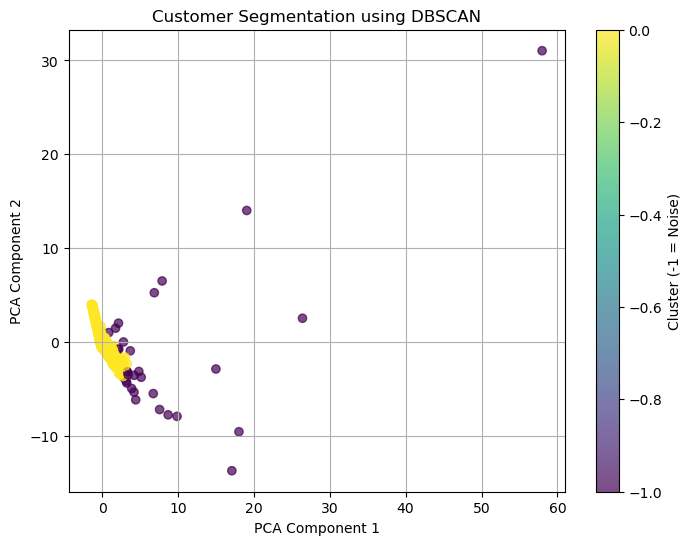

In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap='viridis',
    alpha=0.7
)

plt.title("Customer Segmentation using DBSCAN")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.colorbar(label='Cluster (-1 = Noise)')
plt.grid()
plt.show()